Run mlserver with the following command:

mlflow server \
    --backend-store-uri sqlite:///mlruns.db \
    --default-artifact-root ./mlruns \
    --host 0.0.0.0 \
    --port 5000

then execute the notebook

we will be using the dataset with the variables for vowels, that is the result of the notebook 2024_07_19_exploratory_data_analysis.ipynb. the name is no_nulls_dataset.csv

This notebook is the same as the notebook train_modell_vowels_v4_20250302_no_spectograms_features.ipynb, but without the mel features.


In [27]:
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
import time
import mlflow

# Esto es para poder importar las funciones de src
os.chdir('/Users/antonellaschiavoni/Documents/Antonella/tesis-ciencia-de-datos')

# MLflow configuration

In [28]:
# Set MLflow tracking URI
mlflow.set_tracking_uri('http://localhost:5000')

# Create an experiment if it doesn't exist
experiment_name = f"Age Prediction Experiment {datetime.now().strftime('%Y-%m-%d_%H-%M')}"
try:
    # mlflow.create_experiment(experiment_name)
    mlflow.set_experiment(experiment_name)
except mlflow.exceptions.MlflowException as e:
    # If the experiment already exists, you can catch the exception and continue
    print(f"Experiment '{experiment_name}' already exists.")

# Start an MLflow experiment
mlflow.start_run(run_name="Age Prediction Experiment - Voice Vowels - V4 - No Mel Features", experiment_id="0")

start_time = time.time()


2025/03/02 22:00:37 INFO mlflow.tracking.fluent: Experiment with name 'Age Prediction Experiment 2025-03-02_22-00' does not exist. Creating a new experiment.


Exception: Run with UUID 25f22dc1b45e4196bdc0fa71d9bf960f is already active. To start a new run, first end the current run with mlflow.end_run(). To start a nested run, call start_run with nested=True

# Load the dataset

Using the dataset with the variables for vowels, that is the result of the notebook 2024_07_19_exploratory_data_analysis.ipynb. the name is no_nulls_dataset.csv

In [29]:
dataset = Path("/Users/antonellaschiavoni/Documents/Antonella/tesis-ciencia-de-datos/data/processed/datasets/vowel_features/no_nulls_dataset.csv")
df = pd.read_csv(dataset)

mlflow.log_param("initial_data_path", str(dataset))


'/Users/antonellaschiavoni/Documents/Antonella/tesis-ciencia-de-datos/data/processed/datasets/vowel_features/no_nulls_dataset.csv'

## Visualize Columns


In [30]:
# Print column types summary
print("\nColumn Types Summary:")
print("-" * 50)
print(df.dtypes.value_counts())

# Print basic information about the DataFrame
print("\nDataFrame Info:")
print("-" * 50)
df.info(show_counts=True)


Column Types Summary:
--------------------------------------------------
float64    39
object      4
int64       1
Name: count, dtype: int64

DataFrame Info:
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108 entries, 0 to 107
Data columns (total 44 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   file                   108 non-null    object 
 1   label                  108 non-null    object 
 2   f0_mean                108 non-null    float64
 3   f1_mean                108 non-null    float64
 4   f2_mean                108 non-null    float64
 5   f3_mean                108 non-null    float64
 6   intensity_mean         108 non-null    float64
 7   jitter_local           108 non-null    float64
 8   shimmer_local          108 non-null    float64
 9   f0_median              108 non-null    float64
 10  f0_std                 108 non-null    float64
 11  samp

# Feature Engineering

In [31]:
# Map gender to 0 and 1
df.loc[:, "sex_numeric"] = df["sex"].map({"Male": 0.0, "Female": 1.0})

Let's create a new column with the age category balanced, calculated by the quantiles of the age column.

Why do we need to create a new column with the age category? because we want to predict the age category based on the spectrogram features and dataset feature. We will use the quantiles to create the age category. The quantiles are the values that divide the data into equal parts, so this will help us to balance the classes.

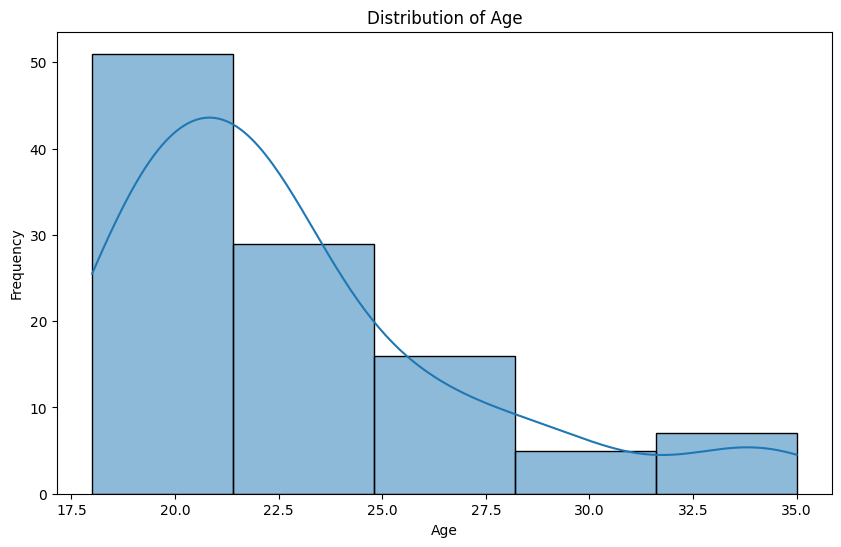

In [32]:
import seaborn as sns
# Plot the distribution of the age category

plt.figure(figsize=(10, 6))
sns.histplot(df["age"], bins=5, kde=True)
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

In [33]:
import numpy as np


# Calculate quantiles for dividing into thirds
quantiles = df['age'].quantile([0.33, 0.66]).to_dict()

def categorize_age(age):
    if age <= quantiles[0.33]:
        return '10-20'
    elif age <= quantiles[0.66]:
        return '21-23'
    else:
        return '24-39'

# Apply the function to create the new column
df['age_category_balanced'] = df['age'].apply(categorize_age)

# Verify the distribution
print(df['age_category_balanced'].value_counts())

age_category_balanced
21-23    42
10-20    36
24-39    30
Name: count, dtype: int64


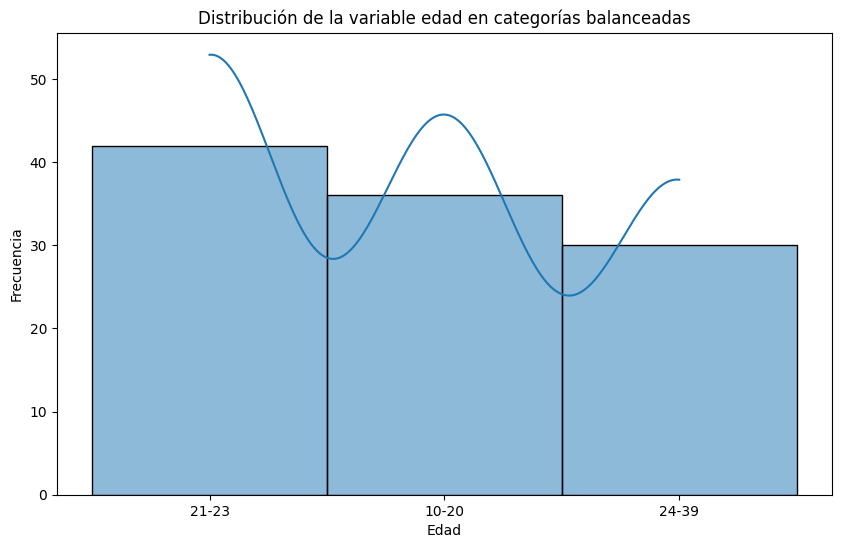

In [34]:
# Data Visualization

import seaborn as sns
# Plot the distribution of the age category

plt.figure(figsize=(10, 6))
sns.histplot(df["age_category_balanced"], bins=5, kde=True)
plt.title("Distribución de la variable edad en categorías balanceadas")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.show()

#### Map age category to numeric

In [35]:
df.loc[:, "age_category_balanced_numeric"] = df["age_category_balanced"].map({"10-20": 0, "21-23": 1, "24-39": 2})

df["age_category_balanced_numeric"].value_counts()

age_category_balanced_numeric
1    42
0    36
2    30
Name: count, dtype: int64

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108 entries, 0 to 107
Data columns (total 47 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   file                           108 non-null    object 
 1   label                          108 non-null    object 
 2   f0_mean                        108 non-null    float64
 3   f1_mean                        108 non-null    float64
 4   f2_mean                        108 non-null    float64
 5   f3_mean                        108 non-null    float64
 6   intensity_mean                 108 non-null    float64
 7   jitter_local                   108 non-null    float64
 8   shimmer_local                  108 non-null    float64
 9   f0_median                      108 non-null    float64
 10  f0_std                         108 non-null    float64
 11  sample_name                    108 non-null    object 
 12  attrac-voicesent-f             108 non-null    flo

#### Drop the columns that are relatewd to the voice sent

In [37]:
df.drop(columns=[col for col in df.columns if "-voicesent-" in col], inplace=True)

#### Create final dataframe to train the model. Drop the columns that are not needed.

In [38]:

df_features = df.drop(columns=["file", "label", "sample_name", "age", "sex", "age_category_balanced"])

In [39]:
df_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108 entries, 0 to 107
Data columns (total 26 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   f0_mean                        108 non-null    float64
 1   f1_mean                        108 non-null    float64
 2   f2_mean                        108 non-null    float64
 3   f3_mean                        108 non-null    float64
 4   intensity_mean                 108 non-null    float64
 5   jitter_local                   108 non-null    float64
 6   shimmer_local                  108 non-null    float64
 7   f0_median                      108 non-null    float64
 8   f0_std                         108 non-null    float64
 9   attrac-voicevow-f              108 non-null    float64
 10  attrac-voicevow-m              108 non-null    float64
 11  attrac-voicevow-all            108 non-null    float64
 12  mascfem-voicevow-f             108 non-null    flo

#### Create df mel strengths dataframe

#### Select target and remove it from the features dataframe

In [40]:
# Select target
target = "age_category_balanced_numeric"
y = df_features[target].values

# Remove the target from the features dataframe
df_features.drop(columns=[target], inplace=True)

In [41]:
df_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108 entries, 0 to 107
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   f0_mean               108 non-null    float64
 1   f1_mean               108 non-null    float64
 2   f2_mean               108 non-null    float64
 3   f3_mean               108 non-null    float64
 4   intensity_mean        108 non-null    float64
 5   jitter_local          108 non-null    float64
 6   shimmer_local         108 non-null    float64
 7   f0_median             108 non-null    float64
 8   f0_std                108 non-null    float64
 9   attrac-voicevow-f     108 non-null    float64
 10  attrac-voicevow-m     108 non-null    float64
 11  attrac-voicevow-all   108 non-null    float64
 12  mascfem-voicevow-f    108 non-null    float64
 13  mascfem-voicevow-m    108 non-null    float64
 14  mascfem-voicevow-all  108 non-null    float64
 15  domin-voicevow-f      1

#### Combine features and mel strengths

In [42]:
# Combine them with the mels strength features
X = df_features

# Convert all columns names to string, otherwise the model will not work and will throw an error
X.columns = X.columns.astype(str)

print(f"Amount of features: {len(X.columns)}")

Amount of features: 25


#### Display class distribution

In [43]:
pd.Series(y).value_counts()

1    42
0    36
2    30
Name: count, dtype: int64

##### Class distribution after balancing are better than in experiment V1

### Split the data into train, and test sets

In [44]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# Split into train, test, and validation sets
x_tr, x_te, y_tr, y_te = train_test_split(
    X, y, train_size=0.7, shuffle=True, stratify=y, random_state=0
)

# Print dataset sizes
print(f"Train set size: {x_tr.shape}")
print(f"Train set class distribution: \n{pd.Series(y_tr).value_counts()}")
print(f"Test set size: {x_te.shape}")
print(f"Test set class distribution: \n{pd.Series(y_te).value_counts()}")

Train set size: (75, 25)
Train set class distribution: 
1    29
0    25
2    21
Name: count, dtype: int64
Test set size: (33, 25)
Test set class distribution: 
1    13
0    11
2     9
Name: count, dtype: int64


#### Apply SMOTE to balance the classes

In [45]:
# Apply SMOTE only on the training set
smote = SMOTE(random_state=42)
x_tr_resampled, y_tr_resampled = smote.fit_resample(x_tr, y_tr)

# Print resampled training set size
print(f"Resampled Train set size: {x_tr_resampled.shape}")
print(f"Resampled Train set class distribution: \n{pd.Series(y_tr_resampled).value_counts().sort_index()}")

Resampled Train set size: (87, 25)
Resampled Train set class distribution: 
0    29
1    29
2    29
Name: count, dtype: int64


#### Log the size of the train and test sets in mlflow

In [46]:

# Log the size of the train and test sets
mlflow.log_param("train_set_size", x_tr_resampled.shape)
mlflow.log_param("train_set_class_distribution", pd.Series(y_tr_resampled).value_counts().sort_index())
mlflow.log_param("test_set_size", x_te.shape)
mlflow.log_param("test_set_class_distribution", pd.Series(y_te).value_counts().sort_index())


MlflowException: INVALID_PARAMETER_VALUE: Changing param values is not allowed. Param with key='train_set_size' was already logged with value='(87, 153)' for run ID='25f22dc1b45e4196bdc0fa71d9bf960f'. Attempted logging new value '(87, 25)'.

The cause of this error is typically due to repeated calls
to an individual run_id event logging.

Incorrect Example:
---------------------------------------
with mlflow.start_run():
    mlflow.log_param("depth", 3)
    mlflow.log_param("depth", 5)
---------------------------------------

Which will throw an MlflowException for overwriting a
logged parameter.

Correct Example:
---------------------------------------
with mlflow.start_run():
    with mlflow.start_run(nested=True):
        mlflow.log_param("depth", 3)
    with mlflow.start_run(nested=True):
        mlflow.log_param("depth", 5)
---------------------------------------

Which will create a new nested run for each individual
model and prevent parameter key collisions within the
tracking 

# Define ML pipeline

In [26]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import PowerTransformer, RobustScaler, StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
import numpy as np

# Define separate preprocessing pipelines
preprocessor_robust = ColumnTransformer([('num', RobustScaler(), df_features.columns.tolist())])
preprocessor_power = ColumnTransformer([('num', PowerTransformer(), df_features.columns.tolist())])
preprocessor_standard = ColumnTransformer([('num', StandardScaler(), df_features.columns.tolist())])

pipe = Pipeline(
    [
        ("preprocessor", preprocessor_standard),
        ("rf", RandomForestClassifier(class_weight="balanced")),  # Random Forest model
    ]
)

# Update the hyperparameter grid for Random Forest
grid = {
    "preprocessor__num": [preprocessor_standard, preprocessor_power, preprocessor_robust],
    "rf__n_estimators": [5,25,50,75,100,125,150,175,200],  # Number of trees in the forest
    "rf__max_depth": [None, 1, 2, 3, 4, 5, 6],     # Maximum depth of trees
    "rf__min_samples_split": [2,3,4,5,6], # Minimum samples required to split an internal node
    "rf__min_samples_leaf": [2,4,6,8,10],   # Minimum samples required at a leaf node
}

cv=StratifiedKFold(n_splits=6, shuffle=True, random_state=42)

# Create GridSearchCV object for hyperparameter tuning with cross-validation
grid_cv = GridSearchCV(pipe, grid, cv=cv, return_train_score=True, verbose=1)

# Train GridSearchCV
model = grid_cv.fit(x_tr, y_tr)

Fitting 6 folds for each of 4725 candidates, totalling 28350 fits


KeyboardInterrupt: 

In [ ]:
mlflow.log_param("grid_search_parameters", grid)

In [ ]:
# Log cross-validation metrics
cv_results = model.cv_results_
for i in range(len(cv_results['params'])):
    with mlflow.start_run(nested=True):
        mlflow.log_params(cv_results['params'][i])
        mlflow.log_metric("mean_test_score", 
                         cv_results['mean_test_score'][i])

#### Log the model

In [ ]:
from mlflow.models.signature import infer_signature

 # Infer model signature
signature = infer_signature(x_tr, model.predict(x_tr))

# Register the model
mlflow.sklearn.log_model(sk_model=model, artifact_path="model", signature=signature)

#### Log the best score and parameters

In [ ]:
mlflow.log_metric("best_score", model.best_score_)

# For logging the best parameters, you need to convert them into a string or log them individually
best_params = model.best_params_
for param, value in best_params.items():
    mlflow.log_param(param, value)

mlflow.log_param("best_estimator", str(model.best_estimator_))

#### Select the columns we are interested in to plot the grid search results

In [ ]:
# Select the columns we are interested in
col_of_interest = [
    "param_preprocessor__num",  # Preprocessing scaler
    "param_rf__n_estimators",   # Number of trees
    "param_rf__max_depth",      # Maximum depth of trees
    "param_rf__min_samples_split",  # Minimum samples to split a node
    "param_rf__min_samples_leaf",   # Minimum samples at a leaf node
    "mean_test_score",          # Mean test score from cross-validation
    "mean_train_score",         # Mean train score from cross-validation
    "std_test_score",           # Standard deviation of test scores
    "std_train_score",          # Standard deviation of train scores
]

# Collect results in a DataFrame
cv_results = pd.DataFrame(grid_cv.cv_results_)
cv_results = cv_results[col_of_interest]

# Show the dataframe sorted according to our performance metric
cv_results.sort_values("mean_test_score", ascending=False)

In [ ]:
# Extract all transformers
print("All Preprocessors:")
print("-" * 50)
for i, column_transformer in enumerate(grid["preprocessor"], 1):
    # Get the transformer from the ColumnTransformer
    transformer = column_transformer.get_params()['transformers'][0][1]
    
    print(f"\n{i}. Column Transformer:")
    print(f"   - Name: {column_transformer.get_params()['transformers'][0][0]}")
    print(f"   - Transformer: {transformer}")
    print(f"   - Type: {type(transformer).__name__}")
    print(f"   - Parameters: {transformer.get_params()}")

# If you want to store them in a list:
transformers = [ct.get_params()['transformers'][0][1] 
               for ct in grid["preprocessor"]]

# Print the extracted transformers list
print("\nExtracted transformers list:")
print("-" * 50)
for i, t in enumerate(transformers, 1):
    print(f"{i}. {type(t).__name__}")

### Print Training and Test Curves

In [ ]:
import matplotlib.pyplot as plt

# Select only numeric columns for grouping
numeric_columns = [
    "mean_test_score",
    "mean_train_score",
    "std_test_score",
    "std_train_score"
]

# Group by n_estimators and calculate mean scores
grouped = cv_results.groupby("param_rf__n_estimators")[numeric_columns].mean()

# Plot mean train and test scores
f = plt.figure(figsize=(8, 6))
plt.plot(grouped.index, grouped["mean_train_score"], label="Train Score", marker="o")
plt.plot(grouped.index, grouped["mean_test_score"], label="Test Score", marker="o")
plt.xlabel("Número de estimadores")
plt.ylabel("Score")
plt.title("Performance vs. Número de estimadores")
plt.legend()
plt.grid(True)
plt.show()

mlflow.log_figure(f, "performance_vs_n_estimators.png")


In [ ]:
# Select only numeric columns for aggregation
numeric_columns = [
    "mean_test_score",
    "mean_train_score",
    "std_test_score",
    "std_train_score"
]

# Group by max_depth and calculate mean scores
grouped = cv_results.groupby("param_rf__max_depth")[numeric_columns].mean()

# Plot mean train and test scores
import matplotlib.pyplot as plt

f = plt.figure(figsize=(8, 6))
plt.plot(grouped.index, grouped["mean_train_score"], label="Train Score", marker="o")
plt.plot(grouped.index, grouped["mean_test_score"], label="Test Score", marker="o")
plt.xlabel("Max Profundidad")
plt.ylabel("Score")
plt.title("Performance vs. Max Profundidad")
plt.legend()
plt.grid(True)
plt.show()

mlflow.log_figure(f, "performance_vs_max_depth.png")


In [ ]:
import seaborn as sns

# Pivot table for heatmap (e.g., max_depth vs. n_estimators)
heatmap_data = cv_results.pivot_table(
    values="mean_test_score",
    index="param_rf__max_depth",
    columns="param_rf__n_estimators",
)

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_data, annot=True, fmt=".3f", cmap="viridis")
plt.title("Mean Test Score Heatmap (Max Depth vs. N Estimators)")
plt.xlabel("Number of Estimators")
plt.ylabel("Max Depth")
plt.show()


In [34]:
# Log the plot
mlflow.log_figure(fig, "grid_search_plot.png")


In [ ]:
# Compute score of the best model on the withheld test set
best_clf = model.best_estimator_
best_clf.score(x_te, y_te)

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

def plot_confusion_matrices(y_true, y_pred):
    # Create two subplots
    f, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    # Dynamically set labels based on unique classes
    unique_classes = np.unique(np.concatenate([y_true, y_pred]))
    labels = ["10-19", "20-29", "30-38"][:len(unique_classes)]

    # Plots the standard confusion matrix
    ax1.set_title("Confusion Matrix (counts)")
    ConfusionMatrixDisplay.from_predictions(
        y_true, y_pred, display_labels=labels, xticks_rotation=20, ax=ax1)

    # Plots the normalized confusion matrix
    ax2.set_title("Confusion Matrix (ratios)")
    ConfusionMatrixDisplay.from_predictions(
        y_true, y_pred, display_labels=labels, xticks_rotation=20, ax=ax2,
        normalize="true")

    # Log the confusion matrix
    mlflow.log_figure(f, "confusion_matrix.png")
    
    plt.show()



# Compute test set predictions
predictions = best_clf.predict(x_te)

# Plot confusion matrices
plot_confusion_matrices(y_te, predictions)



In [ ]:
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score

# Realiza predicciones en el conjunto de prueba
y_pred = grid_cv.best_estimator_.predict(x_te)

# Calcula las métricas
print("Classification Report:")
print(classification_report(y_te, y_pred))

# Si quieres calcularlas individualmente:
precision = precision_score(y_te, y_pred, average='weighted')  # Cambia 'weighted' según tus necesidades
recall = recall_score(y_te, y_pred, average='weighted')
f1 = f1_score(y_te, y_pred, average='weighted')

print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")

mlflow.log_metric("precision", precision)
mlflow.log_metric("recall", recall)
mlflow.log_metric("f1_score", f1)

mlflow.log_param("best_estimator", str(model.best_estimator_))
mlflow.log_param("best_score", model.best_score_)
mlflow.log_param("grid_search_parameters", grid)

In [ ]:
#log duration of the experiment
mlflow.log_param("duration", time.time() - start_time)

mlflow.end_run(status="FINISHED")